# Solar Panel Recycling Materials Analysis

### Independent Research Notebook #3 — Solar Panel Recycling

The rapid expansion of the solar photovoltaic (PV) industry as part of the global clean energy transition has intensified concerns around end‑of‑life waste management. In earlier research notebooks, the material composition of a standard utility‑scale crystalline silicon (c‑Si) module was examined, the physical and chemical properties of their constituent materials were analysed, and global cumulative PV waste through 2051 was projected. 

These foundations provide the context for assessing recycling pathways and identifying the technical limitations of current approaches.
The goal of this analysis is to quantify how individual materials contribute to overall recycling inefficiency in PV modules under existing processes. Rather than evaluating recovery rates in isolation, this study combines each material’s mass fraction with its corresponding recovery efficiency to calculate material loss. This system‑level metric highlights which components dominate waste generation and where the largest performance gaps occur. To complement this, the recycling challenges associated with three key module materials are compared across mechanical, thermal, and chemical recycling routes.

Finally, an EVA decomposition–temperature plot is included to illustrate why the encapsulant layer represents a major bottleneck in PV recycling (Riech et al., 2021).

C:\Users\kelly\AppData\Local\Temp\ipykernel_20444\2925114695.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma_r", len(unique_materials))


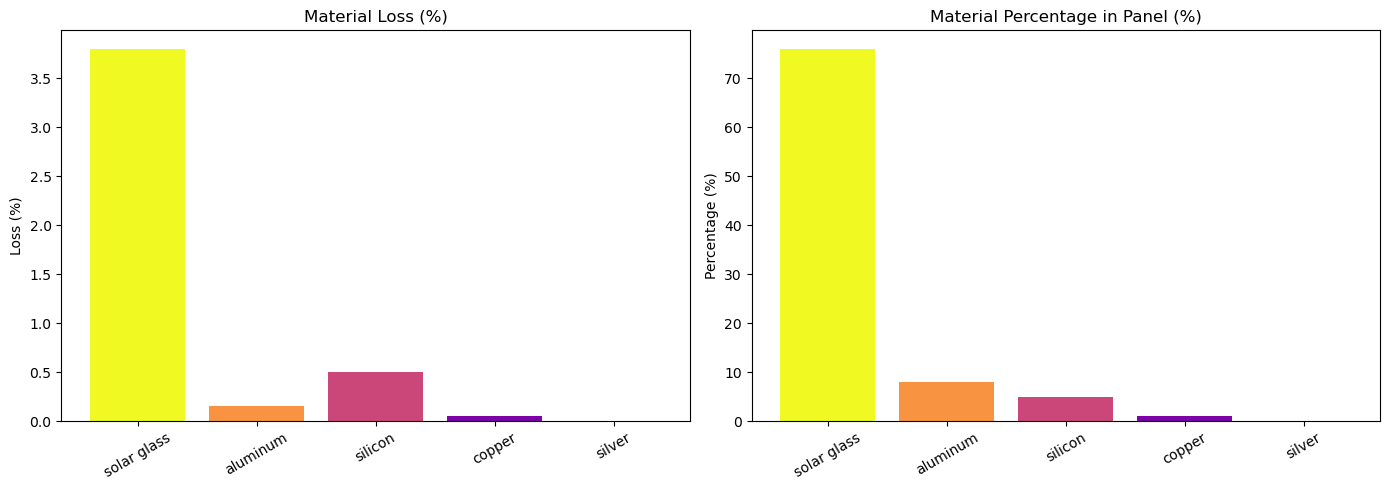

C:\Users\kelly\AppData\Local\Temp\ipykernel_20444\2925114695.py:66: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_sep.replace(rating_map).infer_objects(copy=False)


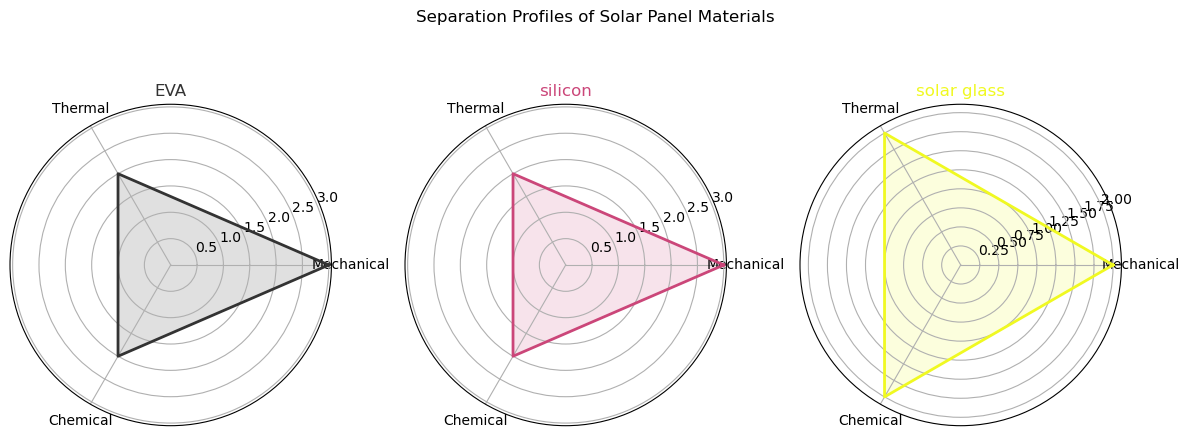

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os

os.chdir(r"C:\Users\kelly\OneDrive\Desktop\solar-panel-recycling-analysis-main")
os.makedirs("results/figures", exist_ok=True)

df = pd.read_csv("data/material_recycling_behaviours.csv")
df.columns = df.columns.str.strip().str.lower()
df = df.dropna(subset=["material"])
df["material"] = df["material"].astype(str).str.strip()

df["%_in_panel"] = df["%_in_panel"].astype(str).str.replace('%', '')
df["recovery_rate"] = df["recovery_rate"].astype(str).str.replace('%', '')

def convert_range(x):
    if '-' in x:
        low, high = x.split('-')
        return (float(low) + float(high)) / 2
    else:
        return float(x)

df["recovery_rate"] = df["recovery_rate"].apply(convert_range)
df["%_in_panel"] = df["%_in_panel"].astype(float)
df["loss (%)"] = df["%_in_panel"] * (1 - df["recovery_rate"] / 100)

total_loss = df["loss (%)"].sum()
df["loss contribution (%)"] = 100 * df["loss (%)"] / total_loss

df_sorted = df.sort_values("loss contribution (%)", ascending=False)
unique_materials = df["material"].unique()

cmap = cm.get_cmap("plasma_r", len(unique_materials))

material_colors = {mat: mcolors.to_hex(cmap(i)) for i, mat in enumerate(unique_materials)}

def get_color(material):
    return material_colors.get(material, "#333333")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [get_color(m) for m in df["material"]]

axes[0].bar(df["material"], df["loss (%)"], color=colors)
axes[0].set_title("Material Loss (%)")
axes[0].set_ylabel("Loss (%)")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(df["material"], df["%_in_panel"], color=colors)
axes[1].set_title("Material Percentage in Panel (%)")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("results/figures/combined_loss_plots.png", dpi=300, bbox_inches="tight")
plt.show()

df_sep = pd.read_csv("data/recycling_types.csv")
df_sep.set_index("material", inplace=True)

rating_map = {"easy": 1, "moderate": 2, "hard": 3}

df_numeric = df_sep.replace(rating_map).infer_objects(copy=False)
df_numeric = df_numeric.fillna(0)

labels = ["Mechanical", "Thermal", "Chemical"]
cols = ["mechanical_separation", "thermal_separation", "chemical_separation"]

materials = ["EVA", "silicon", "solar glass"]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

fig, axes = plt.subplots(1, 3, subplot_kw=dict(polar=True), figsize=(12, 5))

for ax, material in zip(axes, materials):
    values = df_numeric.loc[material][cols].values
    values = np.concatenate((values, [values[0]]))
    color = get_color(material)
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(material, color=color)

plt.suptitle("Separation Profiles of Solar Panel Materials")
plt.tight_layout()
plt.savefig("results/figures/separation_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
import pandas as pd
import os

os.chdir(r"C:\Users\kelly\OneDrive\Desktop\solar-panel-recycling-analysis-main")
os.makedirs("reports", exist_ok=True)

data = {
    "Material": [
        "Solar Glass [^1][^5][^8][^12]",
        "Aluminum [^3][^5][^7]",
        "Silicon [^3][^5]",
        "Copper [^3][4][^5][^7]",
        "Silver [^3][^4][^5][^7]",
 
    ],
    "% in PV Panel": [
        "76%",
        "8%",
        "5%",
        "1%",
        "0.10%"
    ],
    "Recovery Rate": [
        "95%",
        "98%",
        "90%",
        "95%",
        "95%"
    ],
    "Behaviour During Recycling": [
        "Brittle fracture, mechanical and thermal separation",
        "Easily separated mechanically and thermally",
        "Fragile, contamination sensitive. Both thermal and chemical separation techniques have been explored",
        "Conductive, fairly easy to extract thermally",
        "Requires chemical leaching",
    ],
    "Notes": [
        "Often downcycled",
        "Highly recyclable",
        "Hard to retain purity",
        "High value",
        "High economic value",
    ]
}

df_material_properties = pd.DataFrame(data)
df_material_properties.to_csv("results/tables/material_properties_table.csv", index=False)

with open("results/tables/material_properties_table.md", "w", encoding="utf-8") as f:
    f.write(df_material_properties.to_markdown(index=False))

df_material_properties

,Material,% in PV Panel,Recovery Rate,Behaviour During Recycling,Notes
0,Solar Glass [^1][^5][^8][^12,76%,95%,"Brittle fracture, mechanical and thermal separ...",Often downcycled
1,Aluminum [^3][^5][^7],8%,98%,Easily separated mechanically and thermally,Highly recyclable
2,Silicon [^3][^5],5%,90%,"Fragile, contamination sensitive. Both thermal...",Hard to retain purity
3,Copper [^3][4][^5][^7],1%,95%,"Conductive, fairly easy to extract thermally",High value
4,Silver [^3][^4][^5][^7],0.10%,95%,Requires chemical leaching,High economic value


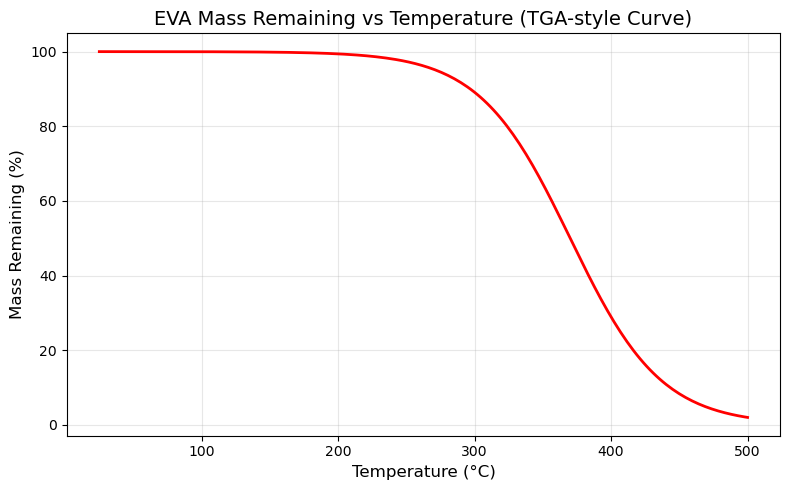

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.chdir(r"C:\Users\kelly\OneDrive\Desktop\solar-panel-recycling-analysis-main")
os.makedirs("results/figures", exist_ok=True)

T = np.linspace(25, 500, 200)
D = 1 / (1 + np.exp(-0.03 * (T - 370)))
W = 100 * (1 - D)

plt.figure(figsize=(8, 5))
plt.plot(T, W, color="red", linewidth=2)

plt.xlabel("Temperature (°C)", fontsize=12)
plt.ylabel("Mass Remaining (%)", fontsize=12)
plt.title("EVA Mass Remaining vs Temperature (TGA-style Curve)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/eva_mass_remaining_vs_temp.png", dpi=300, bbox_inches="tight")
plt.show()

# Markdown

## 1. Data Source

The dataset used for the first 2 graphs contains material fractions within a typical PV panel alongside reported recovery rates. Recovery ranges are converted to average values to simplify and streamline this analysis. Citations for each material are presented next to the material name in the table and below in the references section.

---

## 2. Material Loss in Photovoltaic Recycling

The first stage of the analysis calculates the **material loss (%)** [L], defined as the fraction of each material that is not recovered during recycling. This is determined by combining the material’s proportion within the panel [𝑝] with its recovery rate [𝑟]:

L = 𝑝⋅(1−𝑟/100)

The results show that material loss is not simply a function of recovery rate, but also strongly dependent on the material’s abundance. Materials with moderate recovery rates but high mass fractions can contribute more to overall waste than materials with lower recovery but minimal presence. The material percentage in panel graph exemplifies this. 

EVA was excluded from this material comparison chart because no consistent, peer‑reviewed data were available in the literature to quantify its recovery rate during recycling processes.

Metals such as aluminium, copper, and silver exhibit higher recovery efficiencies and therefore contribute minimally to overall loss.

Solar glass recovery is shown to be difficult to reuse in new PV modules and has a large impact on recycling inefficiencies for the following reasons (Chowdhury et al., 2025): 
- Solar glass makes up the largest proportion of mass in a solar PV module
- Iron contamination can occur during the shredding process, which can hinder quality of glass for new PV modules
- Float glass manufacturers are cautious to use cullets from external sources due to antimony's effect on the glass surface
- Glass sheets are commonly broken during collection/separation
- EVA can be difficult to eliminate from the solar glass

Hot knife and delamination methods can improve the recyclability of solar glass and have the potential to recover the whole sheet (Chowdhury et al., 2025).

---

## 4. Separation Profiles (radar plots) of Solar Panel Materials

To better understand the recyclability of key solar panel components, radar plots were generated for **EVA (ethylene-vinyl acetate)**, **silicon**, and **solar glass**. These plots compare the relative difficulty of three separation methods employed in current recycling processes:

* Mechanical separation
* Thermal separation
* Chemical separation

Each method is scored quantitatively:

* **1 = Easy**
* **2 = Moderate**
* **3 = Hard**

### 4.1 EVA

EVA is a polymer encapsulant used to bind solar panel layers together.

* Mechanical separation is **hard** due to strong adhesion to layers (Moser Baer Solar, 2025).
* Thermal separation is **moderate**, as heat can break down the polymer (Riech et al., 2021)(Moser Baer Solar, 2025).
* Chemical separation is **moderate** (Chowdhury et al., 2025)(Moser Baer Solar, 2025).

### 4.2 Silicon

Silicon forms the core photovoltaic material.

* Mechanical separation is **hard**, as it is fragile and embedded underneath the EVA layer, making it hard to access with mechanical processes alone (Akhter et al., 2024).
* Thermal and chemical separation are **moderate**, requiring controlled conditions to retain purity (Riech et al., 2021).

### 4.3 Solar Glass

Solar glass acts as the primary light‑transmission layer, allowing sunlight to reach the silicon cells with minimal loss.

* Mechanical separation is **moderate** compared to other materials in the solar PV module due to adhesion to EVA. Additionally, recovered solar glass from mechanical methods often results in iron contamination that make it unsuitable for use in a new PV solar module (Chowdhury et al., 2025).
* Thermal separation is **moderate** as this softens the EVA to remove the glass sheet. However, metal impurities can make the solar glass unusable for new PV modules (Chowdhury et al., 2025).
* Chemical separation is **moderate** as this treatment to the EVA layer can lead to better solar glass quality (Chowdhury et al., 2025).

---

## 5. EVA Decomposition vs. Temperature Plot

EVA undergoes a two‑stage thermal degradation process, typically observed in TGA (Thermogravimetric Analysis) experiments (Badiee et al., 2016). To illustrate this behaviour, the decomposition fraction is modelled using a sigmoidal (logistic) function, which captures the characteristic onset, rapid decomposition region, and plateau seen in published TGA curves (Badiee et al., 2016):

D(T)=1/(1+e^(-0.03)(T-370))

This function maps temperature to a decomposition fraction between 0 and 1, where:
- 0 → no decomposition
- 1 → fully decomposed

The value 370 °C sets the midpoint of the decomposition curve.
At T=370 °C, the function gives D=0.5, meaning half of the EVA has decomposed.
This places the onset of decomposition near ~300 °C and the rapid breakdown region between ~330–400 °C, consistent with typical EVA TGA behaviour (Badiee et al., 2016).

The coefficient 0.03 controls the steepness of the curve. A value of 0.03 produces a realistic transition width similar to published TGA curves (Badiee et al., 2016). 

The logistic function is used to approximate thermal degradation curves because it naturally produces (Naya, 2004):

- a flat region at low temperature (stable polymer)
- a steep transition (rapid mass loss)
- a plateau at high temperature (complete decomposition)

To align with standard TGA conventions, the decomposition model was converted from a decomposition fraction to mass remaining (%). This is calculated with the below formula where D(T) is the logistic decomposition fraction:

W(T) = 100(1-D(T))

The resulting curve represents the percentage of EVA mass remaining as temperature increases, consistent with published TGA data for EVA encapsulants.

The TGA‑style curve of EVA mass remaining versus temperature highlights why EVA encapsulant is one of the primary bottlenecks in end‑of‑life solar panel recycling. As depicted in the graph and in the scientific literature, EVA does not decompose significantly below 300 °C. Over a wide temperature range (from ambient up to roughly 250–300 °C), the mass remaining stays close to 100%. This means that:

- Mild heating, even well above typical operating temperatures, does not break down the polymer.
- The encapsulant remains a crosslinked layer that firmly bonds glass, cells, and backsheet together.

The curve only begins to drop noticeably around 300 °C, indicating the onset of significant chemical degradation. Acetic acid release occurs around 345 °C and chain scission usually occurs around 380-480 °C (Badiee et al., 2016)(Marín et al., 1996). To reach these conditions, a recycling process must:

- Supply substantial thermal energy (Zhiyu et al., 2025).
- Treat the evolution of gaseous by‑products (Zhiyu et al., 2025)(Riech et al., 2021).

In contrast with other module components:

- Glass softens at much higher temperatures and does not decompose (EAG Laboratories, n.d.).
- Metals (silver, copper, aluminium) are thermally stable in this temperature range and can be recovered once EVA is removed (American Elements, n.d.).
- This makes EVA the barrier that must be eliminated before other high‑value recoveries can occur.

Ultimately, the TGA behaviour of EVA shows that it remains intact and strongly adhesive up to relatively high temperatures, and only decomposes over a narrow, energy‑intensive temperature window, making it the primary barrier to accessing and recovering the valuable materials within a solar module.

---

## 6. Visual Comparison

The radar plots illustrate how these materials differ in recyclability across the three methods. EVA shows a strong dependence on thermal and chemical processing, while silicon presents a more balanced but consistently challenging profile. In contrast, solar glass is moderately separable mechanically, thermally, and chemically due to its adhesion to EVA.

The EVA decomposition plot demonstrates that EVA is the primary barrier in solar panel recycling. As it remains strongly adhesive up to high temperatures, it only breaks down under conditions that require substantial energy input and careful process control.

Together, these plots underscore the need for material-specific recycling processes. They also highlight that optimizing end‑of‑life recycling methods for photovoltaic modules will require continued refinement of all three separation methods, particularly for polymers and semiconductors that do not respond efficiently to mechanical techniques alone.

---

## 6. Materials Science Interpretation

The findings highlight a fundamental materials challenge in photovoltaic recycling. The primary limitation is not the recoverability of individual materials such as metals, but the presence of polymeric encapsulants that bind the system together. EVA, in particular, exhibits strong cross-linked bonding and thermal stability, making it difficult to remove without energy-intensive or destructive processes (WANREES, 2025)(Peplow, 2022).

This creates a trade-off between durability and recyclability: materials that enhance long-term performance and environmental resistance simultaneously hinder efficient end-of-life separation. As a result, recycling inefficiency is governed by interfacial and structural properties rather than the intrinsic recyclability of individual components (Peplow, 2022).

---

## 7. Assumptions & Model Limitations

### 7.1 Data Availability and Quality

Reported recovery rates for photovoltaic materials vary widely across the literature due to differences in experimental conditions, recycling technologies, and measurement methodologies.

To enable comparison, average values were derived from publicly available peer‑reviewed studies. This introduces uncertainty, as the resulting values may not fully represent the variability or context‑specific performance of individual recycling processes.

EVA was excluded from the material‑loss comparison because no consistent, standardised recovery rate could be identified across peer‑reviewed sources. Its omission affects the completeness of the mass‑balance assessment, particularly given EVA’s known role as a major recycling bottleneck.

### 7.2 Simplification of Recovery Processes

Recovery efficiencies were treated as static, single‑value parameters, whereas in practice they depend on process configuration, equipment type, contamination levels, and module design.

The model therefore reflects generalised behaviour, not the performance of any specific industrial recycling line.

It is also difficult to quantify what percentage of recycled materials are currently reused in new PV modules versus downcycled to other industries. The recovery rates of each material would change depending on the focus. The focus of this research was to obtain recovery rates for reuse in new PV modules.

Material fractions within a “typical” PV module were assumed to be representative. In reality, module composition varies by manufacturer, technology (mono‑Si, poly‑Si, thin‑film), and production year.

### 7.3 Radar Plot Scoring Framework

The quantitative scoring system used in the separation‑difficulty radar plots (1 = easy, 2 = moderate, 3 = hard) is informed by scientific literature but ultimately reflects researcher judgement. These scores should be interpreted as comparative indicators, not absolute measures of process difficulty.

The radar plots simplify complex, multi‑step recycling operations into three high‑level categories (mechanical, thermal, chemical). This abstraction does not capture hybrid or emerging processes.

### 7.4 System Boundary and Scope

The analysis focuses on material recovery and separation difficulty, not on economic, environmental, or energy‑use impacts.
As a result, the findings should not be interpreted as a full life‑cycle assessment (LCA) or techno‑economic analysis (TEA). Further research and analysis should be completed to understand the economic, environmental, and energy use impacts of each recycling method.

Only crystalline‑silicon PV modules were considered. Thin‑film technologies (CdTe, CIGS) have different material compositions and recycling challenges and are outside the scope of this study.

### 7.5 Interpretation of Material Loss

Material loss was calculated using a simplified mass‑balance approach that assumes independent recovery pathways for each material.
In practice, recovery efficiencies can be interdependent (e.g., EVA removal quality affects silicon and glass recovery).

### 7.6 EVA TGA Analysis Assumptions

The decomposition curve is a simplified fit to typical scientific literature behaviour, not an exact kinetic model. The shapes and temperature ranges are realistic, but the curve is not calibrated to a specific experimental dataset.

The plot is represented by a single sigmoidal (logistic) mass‑loss curve with an effective onset around 300 °C and rapid decomposition over a narrow window. The real two‑step process is collapsed into one smooth transition for clarity.

The analysis is modelled as a function of temperature only, not time; Arrhenius kinetics and heating rate effects are not explicitly included.
The curve represents a “typical” non‑isothermal TGA‑style profile, not a prediction for a specific heating rate.

---

## 8. Conclusion

This analysis demonstrates that photovoltaic recycling inefficiency is driven by a combination of material composition and recovery limitations. Polymeric materials, especially EVA, represent a primary bottleneck due to their structural role within the module.

These findings suggest that improving PV recycling requires a shift towards materials design strategies that consider end-of-life disassembly. Current recycling inefficiencies are a direct consequence of designing photovoltaic modules for performance without considering debonding strategies at end-of-life. An eco-design approach would increase circularity rates (Al Zaabi and Ghosh, 2024).

The methods below are critical for achieving a more circular PV industry (Al Zaabi and Ghosh, 2024): 
- Alternative encapsulants
- Reduction in hazardous material use
- PET or Bio-based backsheets
- Substitution of adhesives for O-rings/U-profiles
- Reversible adhesives
- Design for disassembly (DfD) 

---

## 9. References

[^1] Moser Baer Solar (2025) 'Solar panel recycling: Turning end-of-life PV systems into new resources', Available at: https://www.moserbaersolar.com/sustainability-and-environmental-impact/environmental-impact-and-mitigation/solar-panel-recycling-turning-end-of-life-pv-systems-into-new-resources/  (Accessed: [22 March 2026]).

[^2] Riech, I. et al. (2021) ‘Experimental methodology for the separation of materials in the recycling process of silicon photovoltaic panels', Sustainability, 13(4), 2148. Available at: https://pmc.ncbi.nlm.nih.gov/articles/PMC7865510/  (Accessed: [21 March 2026]).

[^3] Akhter, M et al. (2024) ‘Sustainable strategies for crystalline solar cell recycling: A review on recycling techniques, companies, and environmental impact analysis’, Sustainability, 16(13), 5785. Available at: https://doi.org/10.3390/su16135785  (Accessed: [21 March 2026]).

[^4] Piedrahita, A., Cárdenas, L.M. and Zapata, S. (2025) ‘Solar panel waste management: Challenges, opportunities, and the path to a circular economy’, Energies, 18(7), 1844. Available at: https://doi.org/10.3390/en18071844  (Accessed: [21 March 2026]).

[^5] Singh, S., Powar, S., Dhar, A. (2023) ‘End of life management of crystalline silicon and cadmium telluride photovoltaic modules utilising life cycle assessment’, Resources, Conservation and Recycling, 197, 107097. Available at: https://doi.org/10.1016/j.resconrec.2023.107097  (Accessed: [21 March 2026]).

[^6] Rodríguez, R., Pérez, B., Chapartegui, M., Ollo, O. and García, S. (2025) 'Recycling strategies to valorize EVA recovered from PV panels', Poster presented at: EUPVSEC 2025 – European Photovoltaic Solar Energy Conference and Exhibition. EVERPV Project / Tecnalia. Available at: https://everpv.eu/wp-content/uploads/2025/09/EUPVSEC2025_POSTER_Raquel-Rodriguez_TECNALIA.pdf  (Accessed: [21 March 2026]).

[^7] Han, Q et al. (2022) 'Hydrometallurgy recovery of copper, aluminum and silver from spent solar panels', Journal of Environmental Chemical Engineering, 11(1), 109236. Available at: https://www.sciencedirect.com/science/article/abs/pii/S2213343722021091  (Accessed: [21 March 2026]).

[^8] Chowdhury, T., Dehghanimadvar, M., Chang, N.L. and Corkish, R., (2025) 'Review of issues and opportunities for glass supply for photovoltaic production at multiterawatt (TW) scale', Sustainable Energy & Fuels. Available at: DOI: 10.1039/D4SE01567C. (Accessed: [21 March 2026]).

[^9] WANREES (2025) 'How to recycle EVA material from solar panels', Available at: https://www.wanrees.com/how-to-recycle-eva-material-from-solar-panels/. (Accessed: [21 March 2026])  

[^10] Peplow, M. (2022) 'Solar panels face recycling challenge as photovoltaic waste piles up', Chemical & Engineering News. Available at: https://cen.acs.org/environment/recycling/Solar-panels-face-recycling-challenge-photovoltaic-waste/100/i18. (Accessed: [21 March 2026]).

[^11] Al Zaabi, B., Ghosh, A., (2024) ‘Managing photovoltaic Waste: Sustainable solutions and global challenges’, Solar Energy, 283, 112985. Available at: https://www.sciencedirect.com/science/article/pii/S0038092X24006807  (Accessed: [22 March 2026]).

[^12] Surowiak, A. and Wahman, M. (2024) ‘Thermal–mechanical delamination for recovery of tempered glass from photovoltaic panels’, Energies, 17(17), 4444. Available at: https://www.mdpi.com/1996-1073/17/17/4444  (Accessed: [21 March 2026]).

[^13] Badiee, A., Ashcroft, I.A., Wildman, R.D. (2016) 'The thermo-mechanical degradation of ethylene vinyl acetate used as a solar panel adhesive and encapsulant', International Journal of Adhesion and Adhesives, Volume 68, Pages 212-218, ISSN 0143-7496, https://doi.org/10.1016/j.ijadhadh.2016.03.008  (Accessed: [28 March 2026]).

[^14] Marín, M.L., Jiménez, A., López, J. et al. (1996) 'Thermal degradation of ethylene (vinyl acetate)', Journal of Thermal Analysis 47, 247–258, https://doi.org/10.1007/BF01982703  (Accessed: [28 March 2026]).

[^15] Zhiyu, M. et al. (2025) 'Thermal conversion potential of recycled EVA from end-of-life solar panels: Stability assessment, combustion characteristics, and kinetic-thermodynamic profiling', Journal of Environmental Chemical Engineering, Volume 13, Issue 5, 118087, ISSN 2213-3437, https://doi.org/10.1016/j.jece.2025.118087  (Accessed: [28 March 2026]).

[^16] EAG Laboratories, n.d. 'Physical Properties of Glass', Available at: https://www.eag.com/app-note/physical-properties-of-glass/  (Accessed: [28 March 2026]).

[^17] American Elements, n.d. 'Melting Point of Elements', Available at: https://www.americanelements.com/meltingpoint.html  (Accessed: [28 March 2026]).

[^18] Naya, S. (2004) 'Logistic approach to polymer degradation in dynamic TGA', Polymer Degradation and Stability. Available at: doi: 10.1016/J.POLYMDEGRADSTAB.2004.03.006   (Accessed: [28 March 2026]).